# 09 - Ningbo exploratory data analysis

Ningbo First Hospital contributed twelve-lead resting ECGs to the PhysioNet/CinC Challenge 2021 (release
1.0.3, `training/ningbo`). Each record is a WFDB header and a MATLAB signal file, and the header lists age,
sex and **SNOMED CT diagnosis codes** assigned by physicians. The Chapman/Shaoxing records of the same
Challenge (`JS00001` to `JS10646`) come from the same combined release; Ningbo continues the numbering from
`JS10647`. This notebook describes the dataset: its files, demographics, codes and what they mean for the
project's binary label, what the stored signals contain, how they were filtered, and which recordings are
stored more than once, including in Chapman.

The files are read from `data/raw/challenge-2021/1.0.3/`, checked against the release's `SHA256SUMS.txt`
(`data/acquisition/ningbo_verification.json`). The analysis code is in `ecg_experiment/eda/ningbo.py`, and
the code-to-label mapping in `ecg_experiment/challenge_labels.py`.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wfdb

from ecg_experiment import challenge_labels
from ecg_experiment.ecg_quality import EXCLUSION_REASONS, REVIEW_FLAGS
from ecg_experiment.eda import ningbo
from ecg_experiment.eda.cross import combined_summary
from ecg_experiment.eda.signals import LEADS, plot_ecg, problem_counts
from ecg_experiment.eda.sph import load_metadata as load_sph
from ecg_experiment.eda.sph import sph_summary
from ecg_experiment.eda.stats import age_band, odds_ratios, plot_prevalence, prevalence
from ecg_experiment.ningbo import clean_age

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

all_headers = ningbo.load_headers()
headers = all_headers[all_headers["has_signal"]].copy()
quality, leads, fingerprints = ningbo.record_scan(headers)
summary = ningbo.ningbo_summary(headers)
official = challenge_labels.load_official()
verification = json.loads((ROOT / "data/acquisition/ningbo_verification.json").read_text())
print(f"{len(all_headers):,} headers, {len(headers):,} records with a signal file")

34,904 headers, 34,903 records with a signal file


## 1. Files and format

In [3]:
display(pd.Series({
    "paired records in SHA256SUMS": verification["paired_records"],
    "files expected for the paired records": verification["expected_files"],
    "files matching the official SHA-256": verification["verified_files"],
    "files missing or rejected": ", ".join(verification["missing_files"]),
    "unpaired official stems": ", ".join(verification["unpaired_stems"]),
    "headers read": len(all_headers),
    "records with a signal file": len(headers),
}).to_frame("value"))
display(pd.Series({column: headers[column].value_counts().to_dict() for column in
                   ["fs", "samples", "units", "gain", "lead_names"]}).rename("records per value").to_frame())
display(headers.groupby("group").size().describe().round(0).to_frame("records per folder").T)

,value
paired records in SHA256SUMS,34904
files expected for the paired records,69808
files matching the official SHA-256,69807
files missing or rejected,training/ningbo/g3/JS13118.mat
unpaired official stems,"training/ningbo/g13/JS23074, training/ningbo/g..."
headers read,34904
records with a signal file,34903


,records per value
fs,{500: 34903}
samples,{5000: 34903}
units,{'mV': 34903}
gain,{'1000.0': 34903}
lead_names,"{'I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6': 34903}"


,count,mean,std,min,25%,50%,75%,max
records per folder,35.0,997.0,16.0,906.0,1000.0,1000.0,1000.0,1000.0


**Finding: one uniform format, with three upstream file problems.**

- The release lists 34,904 paired records (69,808 files). 69,807 files match their official SHA-256. The
  signal file of `JS13118` does not: PhysioNet serves it with a different hash on two independent downloads,
  so that record has a header but no usable signal.
- The release also lists a header `S23074.hea` and a signal `JS23074.mat` whose names do not match. They form
  no WFDB record and were not downloaded, so a 34,905th recording is lost upstream.
- The 34,903 usable records all have the same format: 500 Hz, exactly 5,000 samples (10 s), mV with a gain
  of 1,000 (1 µV resolution) and the standard lead order. They are stored in 35 folders of up to 1,000.

## 2. Age and sex

,value
age missing (NaN),55.000
age exactly 0,247.000
ages 1 to 3,0.000
ages 4 to 17,1707.000
oldest,89.000
records at the oldest age,681.000
records one year younger,197.000
median age (0 and NaN removed),61.000
sex unknown,22.000
male share of known sex,0.565


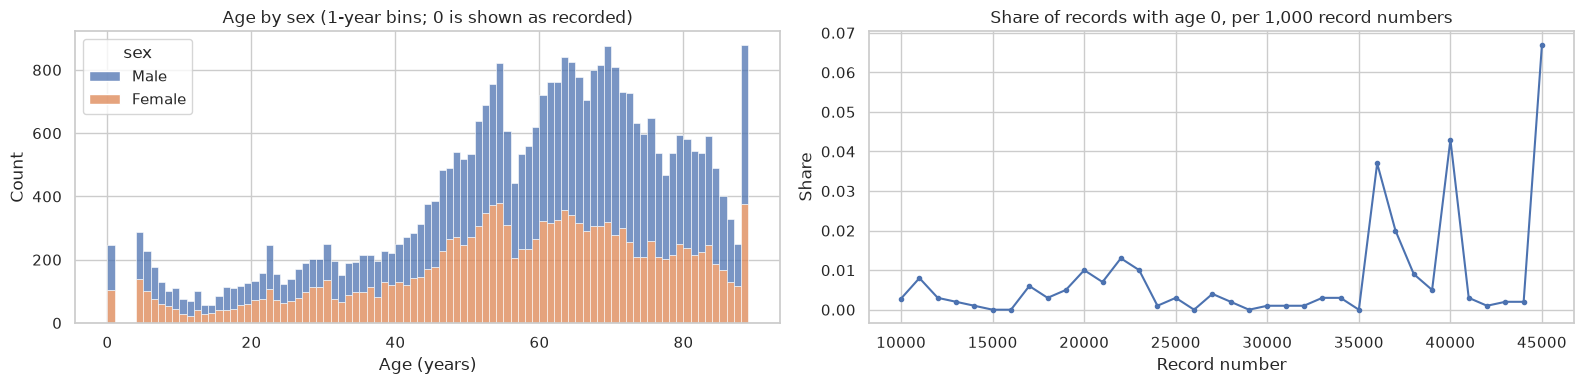

In [4]:
ages = headers["age_years"]
display(pd.Series({
    "age missing (NaN)": int(ages.isna().sum()),
    "age exactly 0": int((ages == 0).sum()),
    "ages 1 to 3": int(ages.between(1, 3).sum()),
    "ages 4 to 17": int(ages.between(4, 17).sum()),
    "oldest": ages.max(),
    "records at the oldest age": int((ages == ages.max()).sum()),
    "records one year younger": int((ages == ages.max() - 1).sum()),
    "median age (0 and NaN removed)": ages[ages > 0].median(),
    "sex unknown": int((headers["sex"] == "Unknown").sum()),
    "male share of known sex": round(headers.loc[headers["sex"] != "Unknown", "sex"].eq("Male").mean(), 3),
}).to_frame("value"))
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
known = headers[headers["sex"].isin(["Male", "Female"])]
sns.histplot(known, x="age_years", hue="sex", binwidth=1, multiple="stack", ax=axes[0])
axes[0].set(title="Age by sex (1-year bins; 0 is shown as recorded)", xlabel="Age (years)")
headers["number"] = headers.index.str[2:].astype(int)
zero_age = (headers["age_years"] == 0).groupby(headers["number"] // 1000 * 1000).mean()
axes[1].plot(zero_age.index, zero_age.to_numpy(), marker=".")
axes[1].set(title="Share of records with age 0, per 1,000 record numbers", xlabel="Record number",
            ylabel="Share")
plt.tight_layout()
plt.show()

**Finding: age has two placeholders and a cap, and 5% of records are children.**

- 55 records have no age (`NaN`) and 247 have age 0. No record is aged 1 to 3, while 287 are aged 4, so 0 is
  a placeholder for a missing age rather than infants. Section 9 confirms it: most Ningbo copies of Chapman
  records have age 0 where Chapman gives an adult age. Age 0 is most common around record numbers 36,000,
  40,000 and 45,000.
- 1,707 records (4.9%) are children aged 4 to 17.
- Ages stop at 89, and 681 records are aged 89 against 197 aged 88, so 89 probably means "89 or older".
- The median age is 61, 56.5% of records with a known sex are from men, and 22 records have an unknown sex.

## 3. SNOMED codes

Each header lists one or more SNOMED CT codes. The official Challenge tables (`dx_mapping_scored.csv` and
`dx_mapping_unscored.csv`) name every code; the 30 scored codes were used for the Challenge ranking.

In [5]:
codes = ningbo.code_counts(headers, official)
per_record = headers["dx_codes"].apply(len)
display(per_record.value_counts().sort_index().rename("records").to_frame().T)
display(codes.head(25)[["name", "group", "scored", "ningbo", "ningbo_share", "chapman_shaoxing", "georgia",
                        "cpsc_2018", "cpsc_2018_extra"]].round(3))
others = ["chapman_shaoxing", "georgia", "cpsc_2018", "cpsc_2018_extra"]
only_ningbo = codes[(codes["ningbo"] > 0) & (codes[others].sum(axis=1) == 0)]
display(pd.Series({
    "codes used in Ningbo": int((codes["ningbo"] > 0).sum()),
    "codes not in either official table": int(codes["name"].isna().sum()),
    "codes used only by Ningbo among the Challenge sources": len(only_ningbo),
    "records carrying one of them": int(headers["dx_codes"].apply(
        lambda values: bool(set(values) & set(only_ningbo.index))).sum()),
}).to_frame("value"))
display(only_ningbo[["name", "group", "scored", "ningbo"]].head(15))

dx_codes,1,2,3,4,5,6,7,8,9,10,11,12
records,17036,8916,4635,2346,1213,512,162,60,15,6,1,1


,name,group,scored,ningbo,ningbo_share,chapman_shaoxing,georgia,cpsc_2018,cpsc_2018_extra
code,,,,,,,,,
426177001,sinus bradycardia,sinus_variant,True,12670,0.363,3889,1677,0,45
164890007,atrial flutter,other,True,7614,0.218,445,186,0,54
426783006,sinus rhythm,sinus_rhythm,True,6299,0.180,1826,1752,918,4
427084000,sinus tachycardia,sinus_variant,True,5687,0.163,1568,1261,0,303
164934002,t wave abnormal,STTC,True,5167,0.148,1876,2306,0,22
55930002,s t changes,STTC,False,4232,0.121,0,6,0,1
55827005,left ventricular high voltage,other,False,4106,0.118,1295,0,0,0
59931005,t wave inversion,STTC,True,2720,0.078,157,812,0,5
427393009,sinus arrhythmia,sinus_variant,True,2550,0.073,0,455,0,11


,value
codes used in Ningbo,80
codes not in either official table,0
codes used only by Ningbo among the Challenge sources,15
records carrying one of them,2228


,name,group,scored,ningbo
code,,,,
61721007,clockwise or counterclockwise vectorcardiograp...,other,False,653
365413008,poor R wave Progression,other,True,638
251223006,tall p wave,other,False,215
106068003,atrial rhythm,other,False,215
733534002,complete left bundle branch block,CD,True,212
425856008,paroxysmal ventricular tachycardia,other,False,109
251205003,prolonged P wave,other,False,106
50799005,atrioventricular dissociation,other,False,59
57054005,acute myocardial infarction,MI,False,49


**Finding: the codes are dominated by rhythm statements, and Ningbo uses codes the others do not.**

- Almost half of the records (17,036) have one code, and the most has 12.
- The most common codes are sinus bradycardia (36.3% of records), atrial flutter (21.8%), sinus rhythm
  (18.0%), sinus tachycardia (16.3%), T-wave abnormality (14.8%), "s t changes" (12.1%) and left
  ventricular high voltage (11.8%).
- All 80 codes Ningbo uses are named in the official tables. 15 of them appear in no other Challenge
  source, on 2,228 records. The most frequent are the vectorcardiographic loop rotation (653), poor R-wave
  progression (638), tall P wave (215), atrial rhythm (215) and complete left bundle branch block (212).
- Ningbo codes bundle branch blocks as "complete" (1,096 complete RBBB, 212 complete LBBB) where the other
  sources mostly use the plain codes. The official scoring equivalences merge the two, and the mapping below
  applies them.

In [6]:
flutter = headers["dx_codes"].apply(lambda values: "164890007" in values)
display(codes.loc[["164889003", "164890007"], ["name", "ningbo", *others]])
display(pd.Series({
    "atrial flutter records": int(flutter.sum()),
    "... also coded sinus rhythm or a sinus variant": int((flutter & headers["dx_codes"].apply(
        lambda values: bool(set(values) & {"426783006", *challenge_labels.SINUS_VARIANTS}))).sum()),
    "median estimated heart rate, flutter (bpm)": summary.loc[flutter[flutter].index, "heart_rate"].median(),
    "median estimated heart rate, others (bpm)": summary.loc[flutter[~flutter].index, "heart_rate"].median(),
}).to_frame("value"))

,name,ningbo,chapman_shaoxing,georgia,cpsc_2018,cpsc_2018_extra
code,,,,,,
164889003,atrial fibrillation,0,1780,570,1221,153
164890007,atrial flutter,7614,445,186,0,54


,value
atrial flutter records,7614.000000
... also coded sinus rhythm or a sinus variant,32.000000
"median estimated heart rate, flutter (bpm)",92.165899
"median estimated heart rate, others (bpm)",61.855670


**Finding: Ningbo never codes atrial fibrillation.** It lists no atrial fibrillation at all, but
atrial flutter on 7,614 records (21.8%), while every other Challenge source has more fibrillation than
flutter. The flutter records have a median estimated heart rate of 92 bpm, against 62 bpm for the rest, and
only 32 of them are also coded with a sinus rhythm. The data cannot tell whether Ningbo's flutter code also
covers what other sources call fibrillation. Any rhythm-level comparison across sources should treat the two
codes together. Neither code is part of the binary label.

## 4. The project's binary label

`ecg_experiment/challenge_labels.py` maps each code to a group: sinus rhythm, a benign sinus variant
(bradycardia, tachycardia, arrhythmia), one of the four PTB-XL superclasses (MI, STTC, CD, HYP), or other.
The four official scoring equivalences are read from the notes of `dx_mapping_scored.csv`. A record is
positive with any superclass code; the primary negative is sinus rhythm alone, and the secondary negative also
allows the sinus variants. Everything else is undefined, never negative.

In [7]:
labels = challenge_labels.label_table(headers["dx_codes"], official)
meta = headers.join(labels)
names = {0: "negative", 1: "positive"}
display(pd.concat([meta[column].map(names).fillna("undefined").value_counts().rename(column)
                   for column in ["primary", "secondary"]], axis=1))
display(meta[list(challenge_labels.SUPERCLASSES)].sum().rename("records").to_frame().T)
undefined = meta[meta["secondary"].isna()]
group_of = codes["group"].to_dict()
display(undefined["dx_codes"].explode().value_counts().head(10).rename("undefined records")
        .to_frame().join(codes[["name", "group"]]))
allowed = {"other", "sinus_rhythm", "sinus_variant"}
only_other = undefined["dx_codes"].apply(lambda values: {group_of[code] for code in values} <= allowed)
print("Undefined records whose codes are all 'other' or sinus codes:", int(only_other.sum()))

,primary,secondary
undefined,17760,6663
positive,12601,12601
negative,4542,15639


,MI,STTC,CD,HYP
records,165.0,10407.0,3893.0,749.0


,undefined records,name,group
dx_codes,,,
164890007,2544,atrial flutter,other
426177001,1978,sinus bradycardia,sinus_variant
55827005,1874,left ventricular high voltage,other
427084000,813,sinus tachycardia,sinus_variant
10370003,717,pacing rhythm,other
39732003,491,left axis deviation,other
426783006,451,sinus rhythm,sinus_rhythm
427172004,422,premature ventricular contractions,other
284470004,414,premature atrial contraction,other


Undefined records whose codes are all 'other' or sinus codes: 6663


**Finding: the binary label is defined for about half of the records, or 81% with sinus variants.**

- With sinus rhythm as the only normal code (primary label), Ningbo has 4,542 negatives, 12,601 positives
  and 17,760 undefined records.
- Sinus bradycardia is so common that the secondary label, which also accepts the benign sinus variants, adds
  11,097 negatives: 15,639 negatives and 6,663 undefined.
- The positives are mostly ST/T findings (STTC, 10,407 records) and conduction disorders (CD, 3,893).
  Hypertrophy (HYP, 749) and infarction (MI, 165) are rare.
- All 6,663 records that stay undefined carry only codes outside the superclasses, besides any sinus code.
  The most common are atrial flutter (2,544), left ventricular high voltage (1,874), paced rhythm (717) and
  left axis deviation (491). Left ventricular high voltage is a voltage criterion, not a hypertrophy
  diagnosis, just as PTB-XL's high-voltage statement is a form statement. The mapping therefore leaves it
  unresolved.

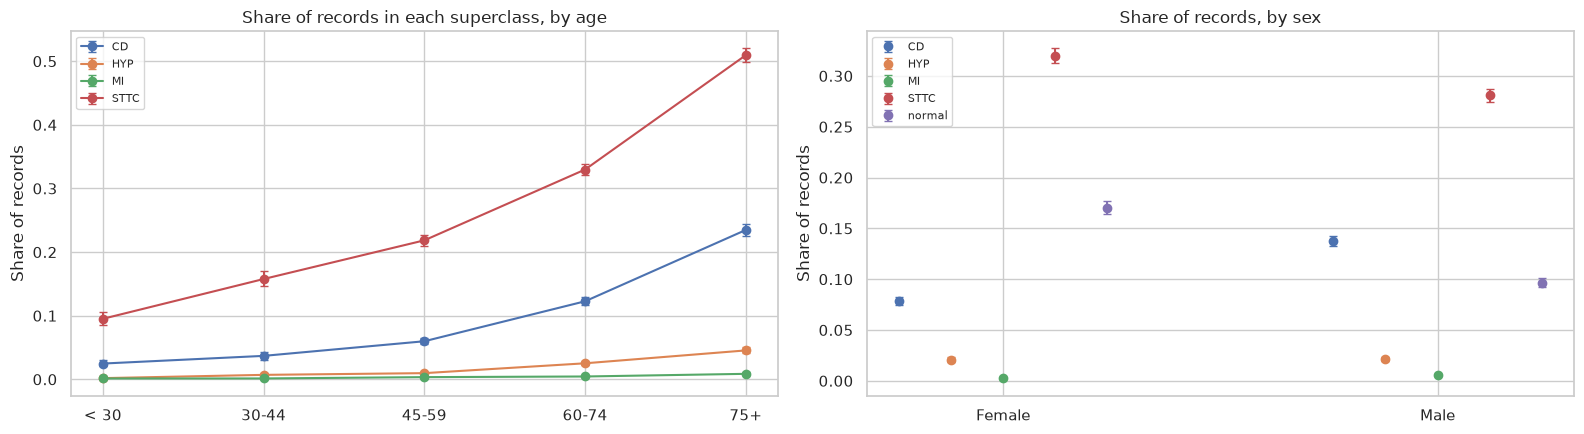

age_band,< 30,30-44,45-59,60-74,75+
outcome,,,,,
CD,0.025,0.037,0.060,0.123,0.235
HYP,0.002,0.007,0.010,0.025,0.045
MI,0.001,0.001,0.003,0.004,0.009
STTC,0.095,0.158,0.219,0.330,0.510
normal,0.141,0.246,0.188,0.102,0.038


sex,Female,Male
outcome,,
CD,0.078,0.138
HYP,0.021,0.022
MI,0.003,0.006
STTC,0.320,0.281
normal,0.171,0.097


,outcome,predictor,odds_ratio,lower,upper,p_value
0,MI,age per 10 years,1.369,1.233,1.519,0.000
1,MI,male,2.230,1.545,3.220,0.000
2,STTC,age per 10 years,1.491,1.469,1.514,0.000
3,STTC,male,0.741,0.706,0.778,0.000
4,CD,age per 10 years,1.612,1.573,1.652,0.000
5,CD,male,1.763,1.638,1.898,0.000
6,HYP,age per 10 years,1.629,1.543,1.719,0.000
7,HYP,male,0.948,0.817,1.100,0.482
8,normal,age per 10 years,0.827,0.815,0.840,0.000
9,normal,male,0.538,0.505,0.574,0.000


In [8]:
meta["age"] = clean_age(meta["age_years"])
meta["age_band"] = age_band(meta["age"])
meta["male"] = meta["sex"] == "Male"
known = meta[meta["sex"].isin(["Male", "Female"]) & meta["age"].notna()].copy()
for name in challenge_labels.SUPERCLASSES:
    known[name] = known[name].astype(bool)
known["normal"] = known["primary"] == 0
outcomes = [*challenge_labels.SUPERCLASSES, "normal"]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_prevalence(prevalence(known, "age_band", list(challenge_labels.SUPERCLASSES)), "age_band", axes[0],
                "Share of records in each superclass, by age")
plot_prevalence(prevalence(known, "sex", outcomes), "sex", axes[1], "Share of records, by sex", connect=False)
plt.tight_layout()
plt.show()
for group in ("age_band", "sex"):
    display(prevalence(known, group, outcomes).pivot(index="outcome", columns=group, values="prevalence")
            .round(3))
display(odds_ratios(known, outcomes).round(3))

**Finding: abnormal findings rise with age, and men are less often normal.**

- The share of normal ECGs (sinus rhythm only) is 14.1% under 30, 24.6% at 30-44 and 18.8% at 45-59, then
  falls to 10.2% at 60-74 and 3.8% at 75 and over (odds 0.83 per decade). Under 30 it is low because many
  young records carry a sinus variant or another code.
- STTC rises from 9.5% under 30 to 51.0% at 75 and over, and CD from 2.5% to 23.5%.
- After adjusting for age, men have about half the odds of a normal ECG (0.54). They have 1.8 times the odds
  of CD and 2.2 times the odds of MI, but lower odds of STTC (0.74). HYP does not differ by sex (p = 0.48).
  The directions for MI, CD and STTC match SPH, the other Chinese hospital; there, men also had more HYP.

## 5. Signal integrity

The same checks as for the other sources, on the full recordings: missing samples, constant or flat leads,
amplitude, and the limb-lead identities.

In [9]:
display(problem_counts(summary).to_frame("records"))
display(summary[["peak_abs_mv", "std", "einthoven_residual", "heart_rate"]]
        .describe(percentiles=[0.01, 0.5, 0.99, 0.999]).round(3).T)
nan_records = summary.index[summary["nan_leads"] > 0]
nan_samples = summary.loc[nan_records, "nan_leads"]
print(f"Records with NaN samples: {len(nan_records)}; they have NaN in {nan_samples.median():.0f} lead(s) "
      f"(median), at most {nan_samples.max():.0f}")
print("Records whose largest sample is exactly 32.767 mV:",
      int((summary["peak_abs_mv"] == 32.767).sum()))

,records
records,34903
any_nan,97
fully_constant_lead,1480
lead_flat_for_1s,1516
lead_over_10mv,749
limb_identity_violated,0
heart_rate_not_estimated,13


,count,mean,std,min,1%,50%,99%,99.9%,max
peak_abs_mv,34903.0,2.781,2.696,0.205,0.927,2.245,13.952,32.767,32.767
std,34903.0,0.164,0.073,0.000,0.045,0.150,0.437,0.706,1.321
einthoven_residual,34903.0,0.001,0.000,0.000,0.001,0.001,0.001,0.001,0.001
heart_rate,34890.0,80.226,29.660,12.397,44.313,70.258,171.429,189.873,198.675


Records with NaN samples: 97; they have NaN in 1 lead(s) (median), at most 3
Records whose largest sample is exactly 32.767 mV: 84


In [10]:
record = str(ningbo.RAW_ROOT / headers.loc[nan_records[0], "path"])
stored = wfdb.rdrecord(record, physical=False).d_signal
physical = wfdb.rdrecord(record).p_signal
missing = np.isnan(physical)
print(f"{nan_records[0]}: {missing.sum()} NaN samples, stored as {np.unique(stored[missing])}")

JS10765: 60 NaN samples, stored as [-32768]


**Finding: clean limb leads, a few missing samples and some saturation.**

- The limb leads obey Einthoven's law to 0.001 mV in every record, the storage resolution, so they were
  derived from two measured leads.
- 97 records have missing samples (NaN) in one lead (median; at most three). The file stores them as
  -32768, the WFDB code for an invalid sample.
- 84 records reach exactly 32.767 mV, the largest value the 16-bit µV format can hold, so they are
  saturated.
- Amplitudes are otherwise ordinary: the median largest sample is 2.25 mV and the 99th percentile 14.0 mV.
  749 records have a sample of 10 mV or more.
- The estimated heart rate has a median of 70 bpm; it could not be estimated for 13 records.

## 6. Leads that are exactly zero

The first Ningbo records smoke-tested had a V6 lead that was zero throughout. How common is this, which leads
does it affect, and does it cover the whole recording or only part of it?

In [11]:
zero = ningbo.zero_lead_table(leads)
whole = leads[leads["run_length"] == 5000]
display(pd.Series({
    "records with a lead constant for the whole record": int(whole["record"].nunique()),
    "... of which the constant value is 0": int(whole.loc[whole["run_value"] == 0, "record"].nunique()),
    "records with a lead constant for 1 s or more but not the whole record": int(
        leads.loc[(leads["run_length"] >= 500) & (leads["run_length"] < 5000), "record"].nunique()),
    "records starting or ending with a sample that is zero in every lead": int(
        ((quality["edge_zero_leading"] > 0) | (quality["edge_zero_trailing"] > 0)).sum()),
}).to_frame("records"))
display(whole.groupby("lead").size().reindex(LEADS, fill_value=0).rename("records").to_frame().T)
display(zero["count"].value_counts().sort_index().rename("records").rename_axis("zero leads").to_frame().T)
display(zero["zero_leads"].value_counts().head(8).rename("records").to_frame())

,records
records with a lead constant for the whole record,1480
... of which the constant value is 0,1480
records with a lead constant for 1 s or more but not the whole record,73
records starting or ending with a sample that is zero in every lead,26


lead,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
records,1,0,0,0,0,0,999,1223,1025,1296,1099,1378


zero leads,1,2,3,4,5,6,7
records,175,28,274,14,23,965,1


,records
zero_leads,
V1;V2;V3;V4;V5;V6,965
V2;V4;V6,198
V6,92
V4;V5;V6,68
V5,23
V3,21
V2,19
V4,14


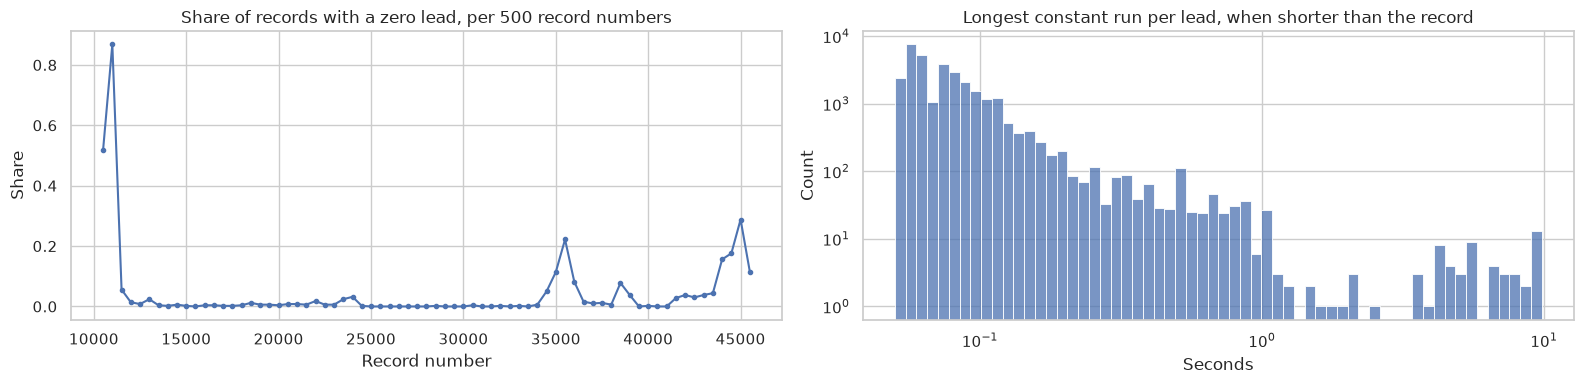

,records,positive_share,undefined_share,median_age
has_zero_lead,,,,
False,33423,0.739,0.498,62.0
True,1480,0.553,0.745,11.0


In [12]:
headers["zero_leads"] = zero["count"].reindex(headers.index).fillna(0)
by_number = (headers["zero_leads"] > 0).groupby(headers["number"] // 500 * 500).mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(by_number.index, by_number.to_numpy(), marker=".")
axes[0].set(title="Share of records with a zero lead, per 500 record numbers", xlabel="Record number",
            ylabel="Share")
partial = leads[(leads["run_length"] >= 25) & (leads["run_length"] < 5000)]
sns.histplot(partial["run_length"] / 500, log_scale=True, bins=60, ax=axes[1])
axes[1].set(title="Longest constant run per lead, when shorter than the record", xlabel="Seconds",
            yscale="log")
plt.tight_layout()
plt.show()
zero_meta = meta.join(zero["count"].rename("zero_count")).fillna({"zero_count": 0})
zero_meta["has_zero_lead"] = zero_meta["zero_count"] > 0
zero_meta["undefined"] = zero_meta["primary"].isna()
display(zero_meta.groupby("has_zero_lead").agg(records=("primary", "size"),
                                               positive_share=("primary", "mean"),
                                               undefined_share=("undefined", "mean"),
                                               median_age=("age", "median")).round(3))

In [13]:
age_group = pd.cut(headers["age_years"], [-1, 0, 17, 200],
                   labels=["age 0", "4-17", "18 and over"])
display(headers.groupby(age_group, observed=True)["zero_leads"].agg(
    records="size", share_with_zero_lead=lambda values: (values > 0).mean(),
    share_with_six_zero_leads=lambda values: (values == 6).mean()).round(3))
print("Zero-lead records aged 4-17:", int(((headers["zero_leads"] > 0) & (age_group == "4-17")).sum()),
      "of", int((headers["zero_leads"] > 0).sum()))

,records,share_with_zero_lead,share_with_six_zero_leads
age_years,,,
age 0,247,0.032,0.016
4-17,1707,0.515,0.344
18 and over,32894,0.018,0.011


Zero-lead records aged 4-17: 879 of 1480


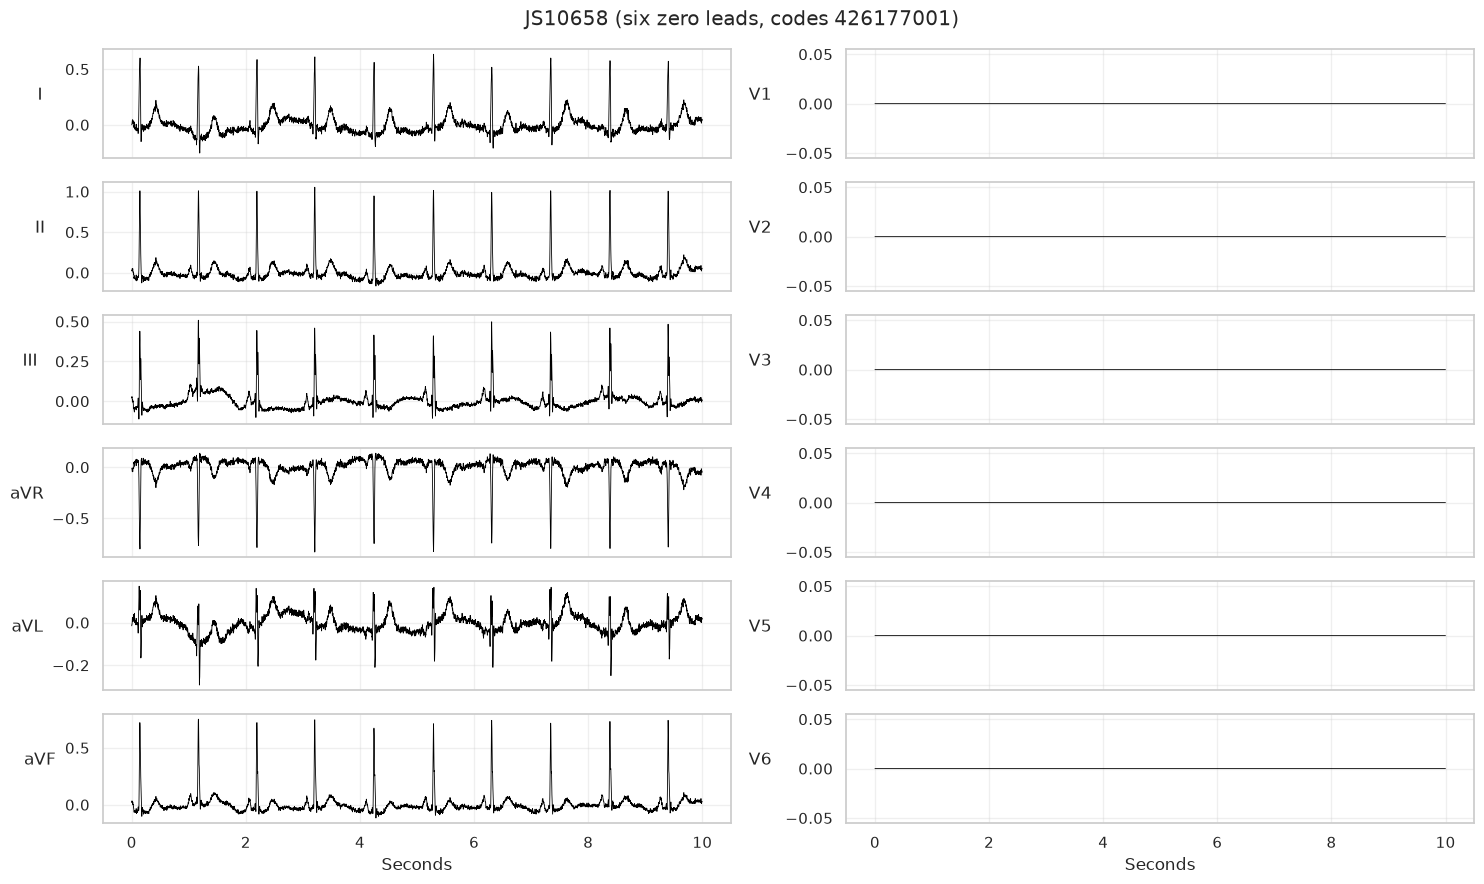

In [14]:
example = zero.index[zero["count"] == 6][0]
signal, fs = ningbo.read_signal(headers.loc[example, "path"])
plot_ecg(signal, fs, f"{example} (six zero leads, codes {','.join(headers.loc[example, 'dx_codes'])})")
plt.show()

**Finding: 1,480 records (4.2%) have whole precordial leads set to zero, mostly children.**

- In every such record the lead is exactly 0 for all 10 s. It is always a precordial lead except in one
  record (lead I).
- 965 records have all six precordial leads zero. The common partial patterns are V2, V4 and V6 (198) and V6
  alone (92).
- Partial filler, as in EchoNext, is almost absent: only 73 records have a lead constant for 1 s or more but
  not for the whole record, and no record starts with zero padding. Constant runs shorter than the record are
  mostly under 0.1 s, the ordinary flat stretches of a signal stored at 1 µV.
- The records cluster in the release: about half of records `JS10647` to `JS11999` (87% in one block of
  500), and about 20-30% near record numbers 35,500 and 45,000, against almost none in between.
- They are strongly tied to age. 51.5% of records of children aged 4-17 have a zero lead, and 34.4% have all
  six precordial leads zero, against 1.8% of adults. 879 of the 1,480 records are children's, and the
  median age of the affected records is 11. As a result, zero-lead records are less often positive (55.3%
  against 73.9% of labeled records) and more often undefined (74.5% against 49.8%). A model could learn
  "missing precordial leads" as a proxy for a child and for the label.

## 7. How the signals were filtered

Sources differ in how much low-frequency (below 0.7 Hz), mains (50 or 60 Hz) and high-frequency (above
40 Hz) power their signals keep, a fingerprint of the recording and export chain. How does Ningbo compare with
the other sources?

,std,baseline_fraction,powerline_50_fraction,high_frequency_fraction,heart_rate
source,,,,,
sph,0.12837,0.00057,0.00024,0.00324,72.11538
cpsc_2018_extra,0.14352,0.00600,0.00049,0.00498,76.62835
cpsc_2018,0.14932,0.00652,0.00054,0.00550,76.92308
mimic,0.13260,0.00830,0.00099,0.01121,74.62687
ptbxl,0.15245,0.01990,0.00071,0.00663,71.25891
code15,0.31570,0.02289,0.00011,0.00140,71.00592
chapman_shaoxing,0.15089,0.02320,0.00119,0.01217,73.52941
georgia,0.14328,0.02385,0.00082,0.00790,75.28231
ningbo,0.14968,0.02474,0.00119,0.01231,70.25761


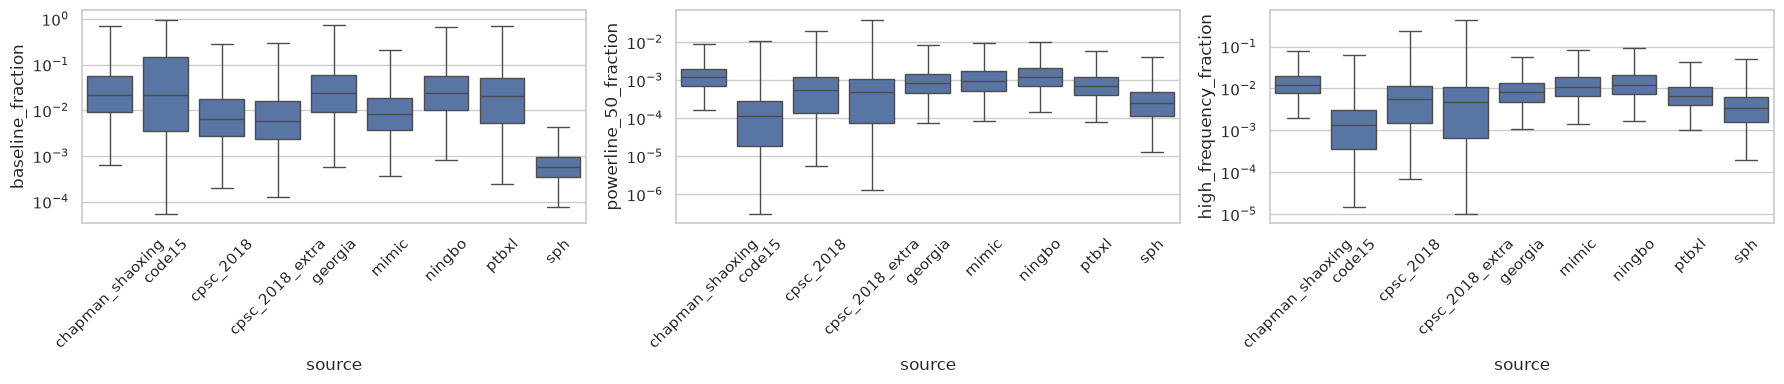

In [15]:
others_summary = combined_summary()
columns = ["std", "baseline_fraction", "powerline_50_fraction", "high_frequency_fraction", "heart_rate"]
sph_table = sph_summary(load_sph())
table = pd.concat([others_summary[["source", *columns]], summary[columns].assign(source="ningbo"),
                   sph_table[columns].assign(source="sph")])
display(table.groupby("source")[columns].median().round(5).sort_values("baseline_fraction"))
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sample = table.groupby("source").sample(3000, random_state=0).reset_index(drop=True)
for axis, column in zip(axes, ["baseline_fraction", "powerline_50_fraction", "high_frequency_fraction"],
                        strict=True):
    sns.boxplot(sample, x="source", y=column, log_scale=True, showfliers=False, ax=axis)
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Finding: Ningbo is essentially unfiltered, with the same fingerprint as Chapman.**

- Its median share of power below 0.7 Hz (0.0247) is the highest of all sources, close to Georgia (0.0239),
  Chapman (0.0232) and PTB-XL (0.0199), and 43 times that of SPH (0.00057).
- Its 50 Hz mains share (0.00119) and high-frequency share (0.0123) are the same as Chapman's (0.00119 and
  0.0122) and the highest of all sources.
- Ningbo and Chapman therefore share one recording and export chain. They are one source family, not two
  independent sites.

## 8. The project quality policy on Ningbo

The quality policy of `ecg_experiment/ecg_quality.py` scores a ten-second window; every Ningbo record is
exactly ten seconds, so it scores the whole record.

In [16]:
rules = [*EXCLUSION_REASONS, *REVIEW_FLAGS, "excluded"]
display(quality[rules].sum().rename("records").to_frame().T)
scored = quality.join(meta[["primary"]]).join(zero["count"].rename("zero_leads"))
scored["reason"] = np.select([scored["zero_leads"].notna(), scored["nonfinite"]], ["zero lead", "nonfinite"],
                             "other")
display(scored[scored["excluded"]].groupby("reason").size().rename("excluded records").to_frame().T)
display(scored.groupby("excluded")["primary"].agg(records="size", positive_share="mean").round(3))

,nonfinite,constant_lead,flat_segment,adc_rail,extreme_amplitude,near_flat_record,noise_dominated,amplitude_over_10mv,limb_identity_violated,strong_baseline_wander,excluded
records,97,1479,1515,13,94,20,74,652,0,2,1784


reason,nonfinite,other,zero lead
excluded records,96,208,1480


,records,positive_share
excluded,,
False,33119,0.739
True,1784,0.587


**Finding: the policy removes 1,784 records (5.1%), mostly the zero-lead ones.**

- All 1,480 zero-lead records fail the constant-lead and flat-segment rules. The other exclusions are 96
  records with missing samples (one more also has a zero lead) and 208 for the remaining rules, mostly
  extreme amplitude (94) and noise (74).
- This is far more than the 0.02-0.65% the policy removed from the other curated sources in the clean
  cohorts v1, because of the children's zero leads.
- Among the review flags, 652 records have a sample over 10 mV, 2 have strong baseline wander, and none
  violate a limb identity.
- The excluded records are less often positive (58.7% against 73.9%).

## 9. Recordings stored more than once

The samples of every record are hashed after rounding to the 1 µV storage resolution, the same hash used for
the other Challenge sources, and as a float32 ten-second window, the hash of the project's training union,
the MIMIC audit and the PTB-XL reference list.

In [17]:
repeated = quality["signal_sha256"].duplicated(keep=False)
within = quality[repeated].join(headers[["age", "sex", "dx"]])
display(within.sort_values("signal_sha256")[["age", "sex", "dx"]])
pairs = ningbo.chapman_pairs(quality, headers, official)
same_age = pairs["age_ningbo"] == pairs["age_chapman"]
display(pd.Series({
    "Ningbo records identical to a Chapman record": len(pairs),
    "distinct Chapman records involved": pairs["chapman"].nunique(),
    "pairs with the same sex": int((pairs["sex_ningbo"] == pairs["sex_chapman"]).sum()),
    "pairs with the same age": int(same_age.sum()),
    "... pairs whose Ningbo age is 0": int((pairs["age_ningbo"] == "0").sum()),
    "pairs with the same code list": int((pairs["dx_codes_ningbo"].apply(sorted)
                                          == pairs["dx_codes_chapman"].apply(sorted)).sum()),
    "pairs with the same primary label": int((pairs["primary_ningbo"].fillna(-1)
                                              == pairs["primary_chapman"].fillna(-1)).sum()),
}).to_frame("pairs"))
shown = ["ningbo", "chapman", "age_ningbo", "age_chapman", "dx_codes_ningbo", "dx_codes_chapman"]
display(pairs[shown].head(8))
numbers = pairs["ningbo"].str[2:].astype(int)
display(numbers.describe()[["min", "50%", "max"]].rename("Ningbo record number").to_frame().T)

,age,sex,dx
record,,,
JS19114,0,Male,"164930006,55930002,164890007,427172004"
JS19115,78,Male,"55930002,164890007,427172004"
JS45461,0,Male,164896001
JS45462,45,Male,164896001
JS33139,51,Female,426177001
JS33140,37,Male,426177001


,pairs
Ningbo records identical to a Chapman record,71
distinct Chapman records involved,71
pairs with the same sex,71
pairs with the same age,17
... pairs whose Ningbo age is 0,53
pairs with the same code list,29
pairs with the same primary label,64


,ningbo,chapman,age_ningbo,age_chapman,dx_codes_ningbo,dx_codes_chapman
0,JS19963,JS07755,42,42,[164890007],[164890007]
1,JS21342,JS10311,0,50,"[426761007, 61721007]",[426761007]
2,JS21746,JS08066,50,50,"[713427006, 164934002, 427084000]","[427084000, 59118001, 164934002]"
3,JS23065,JS10629,0,74,"[164930006, 164917005, 57054005, 425856008]","[426761007, 164931005]"
4,JS23622,JS01992,0,45,"[426783006, 427172004]","[426783006, 17338001]"
5,JS23812,JS02183,67,67,"[426177001, 59118001]","[426177001, 59118001]"
6,JS23830,JS01332,67,83,"[426177001, 59118001]","[426177001, 59118001]"
7,JS24972,JS02757,85,85,"[426177001, 164873001, 55930002]","[426177001, 428750005]"


,min,50%,max
Ningbo record number,13501.0,39808.0,45529.0


In [18]:
receipt_path = ROOT / "outputs/data_quality/ningbo_v1/exact_overlap_receipt.json"
receipt = json.loads(receipt_path.read_text())
display(pd.DataFrame({name: {"hashes compared": item["reference_hashes"],
                             "Ningbo records identical": len(item["overlapping_ningbo_records"])}
                      for name, item in receipt["external"].items() if name != "inputs_sha256"}).T)
print("Near-duplicate pairs (lead II correlation of at least 0.99) that are not identical:")
display(pd.DataFrame(receipt["near_duplicates"]["non_identical_pairs"]))

,hashes compared,Ningbo records identical
clean_100k_plus_labels_v1,115349,68
clean_25k_plus_labels_v1,40349,12
clean_50k_plus_labels_v1,65349,32
georgia_cpsc_cpsc_extra,19921,0
mimic_ssl_200k_audit,197207,0
ptbxl_all_records,21799,0
training_union_500hz_v1,76598,0


Near-duplicate pairs (lead II correlation of at least 0.99) that are not identical:


,correlation,first,second
0,0.990832,JS14182,JS14185


**Finding: 71 Ningbo recordings are copies of Chapman recordings, and 3 are stored twice within
Ningbo.**

- **Within Ningbo:** three pairs of identical recordings, each with adjacent record numbers. In one pair
  (`JS33139`, `JS33140`) the copies list a different sex and age.
- **Against Chapman:** 71 Ningbo records are bit-identical to 71 distinct Chapman records. The Ningbo copies
  are spread from `JS13501` to `JS45529`, not in one block.
  - Sex agrees in all 71 pairs, but age in only 17, and in 53 pairs the Ningbo copy has age 0.
  - The code lists agree in 29 pairs, partly because the two sources use different codes for the same
    finding, such as complete versus plain RBBB. The primary label agrees in 64 of the 71 pairs.
- **Other sources:** no Ningbo record is identical to any of the 21,799 PTB-XL records (which include the
  held-out folds 9 and 10), the training union, the MIMIC 200k audit, or Georgia, CPSC and CPSC-Extra. The
  clean cohorts v1 contain 12, 32 and 68 of the Chapman originals.
- **Near-duplicates:** comparing a scale-free lead II fingerprint at 50 Hz finds the same pairs at a
  correlation of 0.99 or more, plus a single non-identical pair (`JS14182`, `JS14185`, 0.991). Both are paced
  rhythms with atrial flutter, from patients aged 62 and 50, so they are more likely two similar paced ECGs
  than one recording. The pair is kept and marked for review.

## 10. The clean Ningbo manifest

`scripts/data/build_ningbo_clean.py` publishes `data/processed/ningbo_clean_v1/`: one row per record with its
labels, quality result and duplicate status, resolved together with Chapman. No waveform is copied.

In [19]:
clean = json.loads((ROOT / "data/processed/ningbo_clean_v1/metadata.json").read_text())
display(pd.DataFrame({name: clean[name]["primary"] | {"records": clean[name]["records"]}
                      for name in ("evaluation", "training")}))
display(pd.Series(clean["duplicate_status"]).rename("records").to_frame().T)
chapman_statuses = receipt["within_family_statuses"]["chapman_shaoxing"]
display(pd.Series(chapman_statuses).rename("Chapman records").to_frame().T)

,evaluation,training
0.0,4528,4325
1.0,12577,12288
nan,17723,16432
records,34828,33045


,dropped_conflict,dropped_copy,kept,unique
records,11,64,2,34826


,dropped_conflict,dropped_copy,kept,unique
Chapman records,9,13,75,10150


**Finding.** Duplicates are resolved together with Chapman, keeping the lower record name, which is
always the Chapman copy.

- 62 Ningbo copies of agreeing Chapman records and 2 agreeing within-Ningbo copies are dropped.
- 11 Ningbo records are dropped for a conflict: the copies of 9 Chapman records whose labels disagree, and
  both copies of the within-Ningbo pair that disagrees on sex. The 9 Chapman records are listed in the
  receipt so that they are removed from Chapman as well.
- The evaluation set keeps policy-excluded records, as for the other held-out sources: 34,828 records, of
  which 4,528 negative, 12,577 positive and 17,723 undefined.
- The training set also removes the policy exclusions: 33,045 records, of which 4,325 negative, 12,288
  positive and 16,432 undefined.

## 11. Conclusions about the dataset

- **Format.** 34,903 usable ten-second, 500 Hz, mV records in standard lead order. One signal file is
  corrupted upstream and one record is unpaired. The limb leads are derived.
- **Demographics.** Mostly older adults (median 61, 57% men), plus 4.9% children. Missing ages are stored as
  0 or `NaN`, and ages are capped at 89.
- **Labels.** Physician SNOMED codes dominated by rhythm statements. Sinus bradycardia is on 36% of records,
  atrial fibrillation is never coded, and atrial flutter is on 22%. The binary label is defined for 49% of
  records with sinus rhythm as the only normal code, and for 81% when sinus variants also count as normal.
- **Problems.** 4.2% of records have precordial leads stored as zero, mostly children's. A few records have
  missing or saturated samples. 71 recordings are copies of Chapman recordings, often with a placeholder
  age. All of these are handled by `data/processed/ningbo_clean_v1`.
- **Filtering.** Unfiltered, with the same signal fingerprint as Chapman. The two are one source family.